In [6]:
pip install pandas matplotlib scikit-learn streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [7]:
print(df.shape)
print(df['label'].unique())

(2200, 8)
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\4073474659.py:7: UserWarning: Glyph 20316 (\N{CJK UNIFIED IDEOGRAPH-4F5C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\4073474659.py:7: UserWarning: Glyph 29289 (\N{CJK UNIFIED IDEOGRAPH-7269}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\4073474659.py:7: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\4073474659.py:7: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\4073474659.py:7: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_12484\40

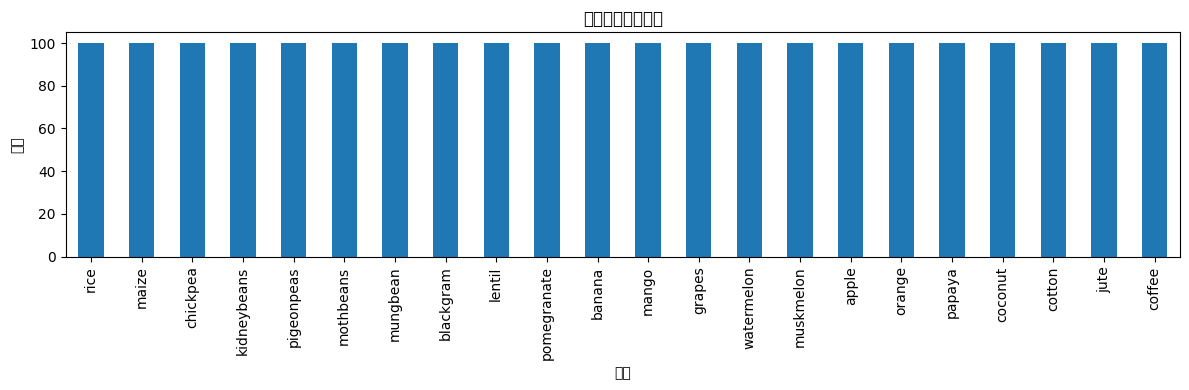

In [8]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', figsize=(12, 4))
plt.title('每种作物的数据量')
plt.xlabel('作物')
plt.ylabel('数量')
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9931818181818182


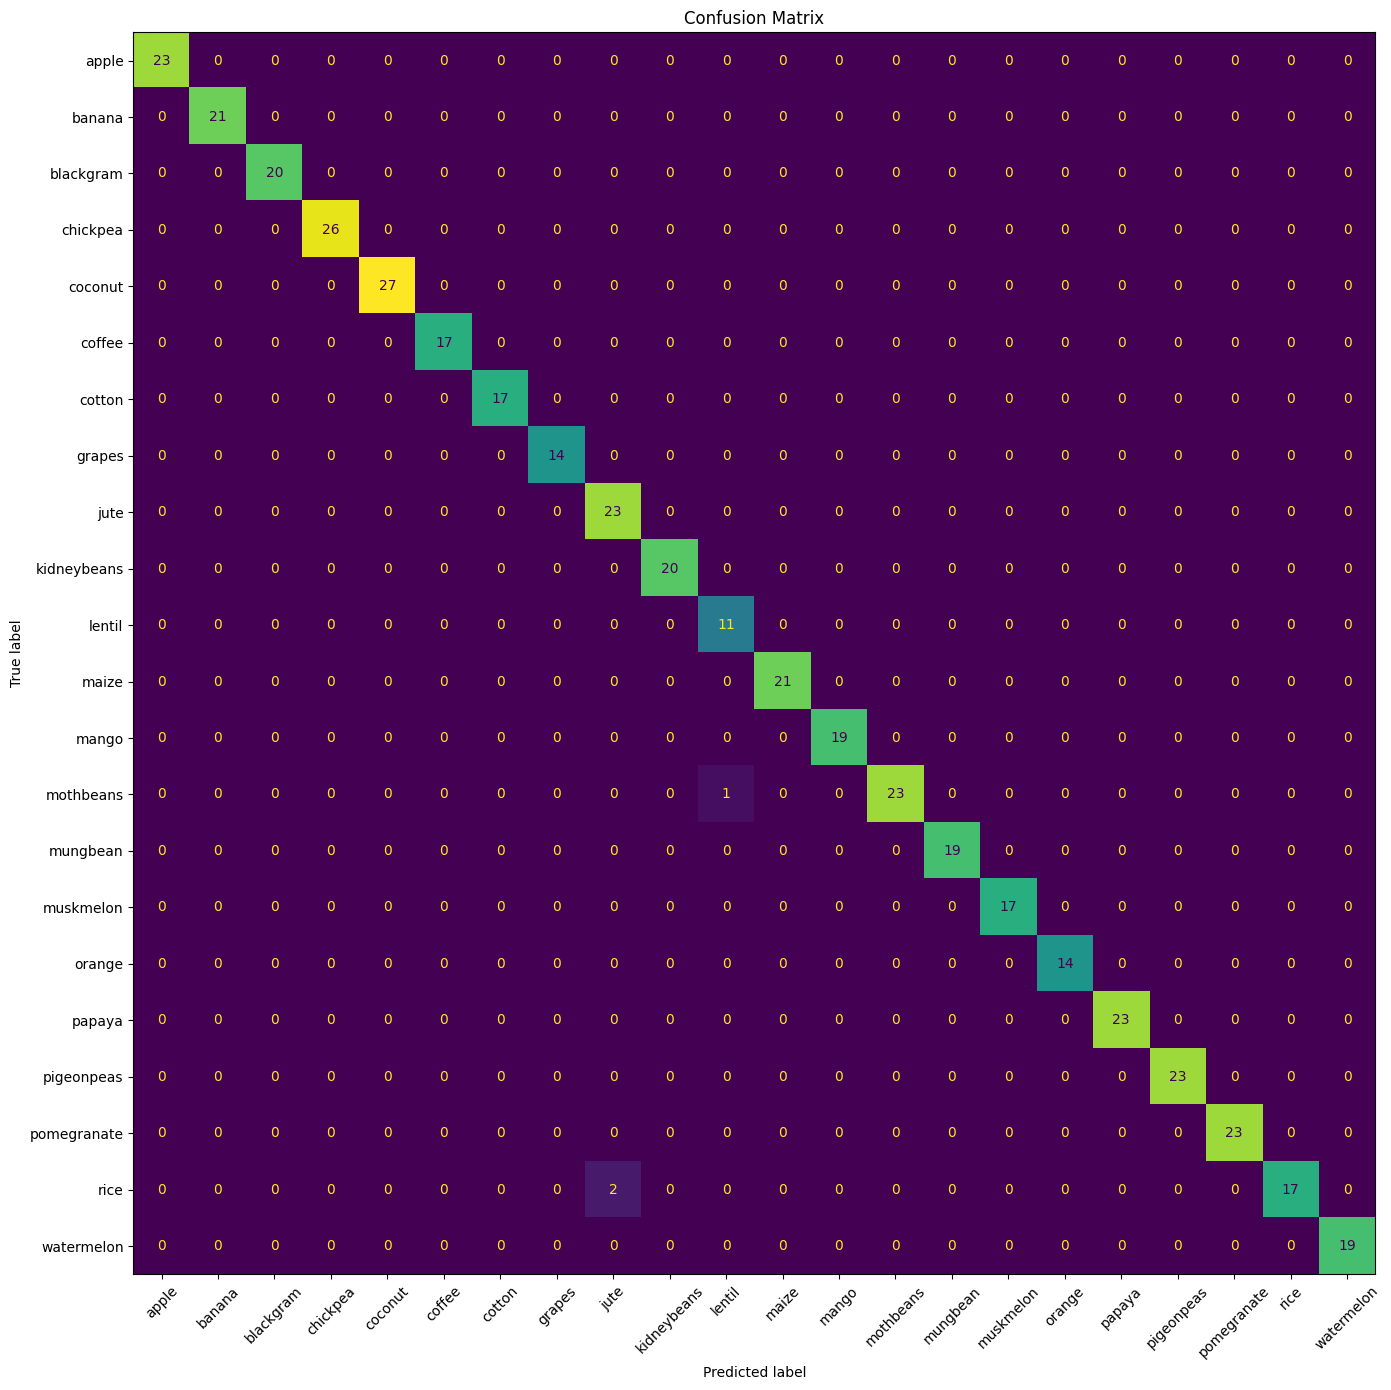

In [10]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(14, 14))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [11]:
import joblib
joblib.dump(model, 'crop_model.pkl')
print("模型已保存")

模型已保存


In [12]:
!pip install xgboost

  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/43/80/0b5a2dfcf5b4da27b0b68d2833f05d77e1a374d43db951fca200a1f12a52/xgboost-2.1.4-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/124.9 MB 495.5 kB/s eta 0:04:13
   ---------------------------------------- 0.1/124.9 MB 770.8 kB/s eta 0:02:42
   ---------------------------------------- 0.1/124.9 MB 770.8 kB/s eta 0:02:42
   ---------------------------------------- 0.2/124.9 MB 876.1 kB/s eta 0:02:23
   ---------------------------------------- 0.2/124.9 MB 876.1 kB/s eta 0:02:23
   ---------------------------------------- 0.3/124.9 MB 1.2 MB/s eta 0:01:45
   ---------------------------------------- 0.4/124.9 MB 1.3 MB/s eta 0:01:38
   ---------------------------------------- 0.5/124.9 MB 1.5 MB/s eta 0:01:26
   ----------------


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train_encoded)

y_pred_xgb = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("Random Forest Accuracy: 0.9931818181818182")

XGBoost Accuracy: 0.9863636363636363
Random Forest Accuracy: 0.9931818181818182


In [15]:
df2 = pd.read_csv("yield_df.csv")
print(df2.shape)
print(df2.dtypes)
print(df2.head())

(28242, 8)
Unnamed: 0                         int64
Area                              object
Item                              object
Year                               int64
hg/ha_yield                        int64
average_rain_fall_mm_per_year    float64
pesticides_tonnes                float64
avg_temp                         float64
dtype: object
   Unnamed: 0     Area         Item  Year  hg/ha_yield  \
0           0  Albania        Maize  1990        36613   
1           1  Albania     Potatoes  1990        66667   
2           2  Albania  Rice, paddy  1990        23333   
3           3  Albania      Sorghum  1990        12500   
4           4  Albania     Soybeans  1990         7000   

   average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  
0                         1485.0              121.0     16.37  
1                         1485.0              121.0     16.37  
2                         1485.0              121.0     16.37  
3                         1485.0          

In [16]:
print("缺失值：")
print(df2.isnull().sum())

print("\n重复行数量：")
print(df2.duplicated().sum())

print("\n基本统计：")
print(df2.describe())

缺失值：
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

重复行数量：
0

基本统计：
         Unnamed: 0          Year    hg/ha_yield  \
count  28242.000000  28242.000000   28242.000000   
mean   14120.500000   2001.544296   77053.332094   
std     8152.907488      7.051905   84956.612897   
min        0.000000   1990.000000      50.000000   
25%     7060.250000   1995.000000   19919.250000   
50%    14120.500000   2001.000000   38295.000000   
75%    21180.750000   2008.000000  104676.750000   
max    28241.000000   2013.000000  501412.000000   

       average_rain_fall_mm_per_year  pesticides_tonnes      avg_temp  
count                    28242.00000       28242.000000  28242.000000  
mean                      1149.05598       37076.909344     20.542627  


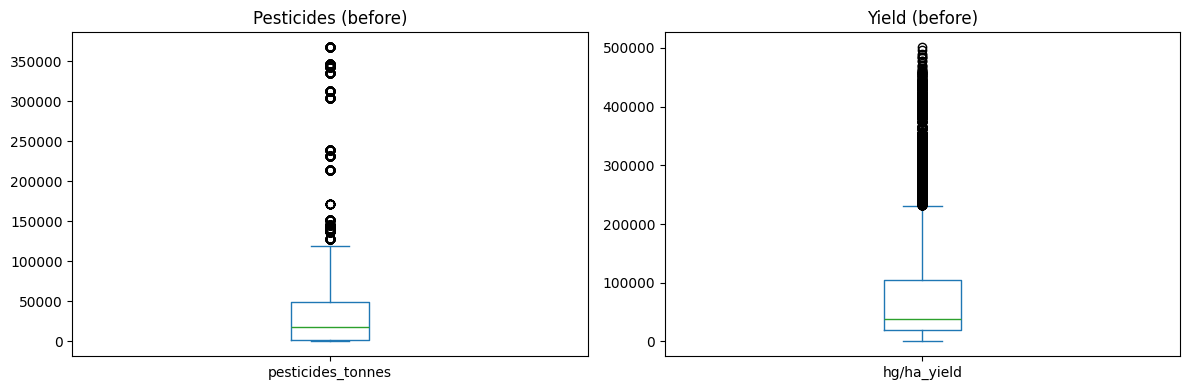

In [17]:
# 删掉多余列
df2 = df2.drop(columns=['Unnamed: 0'])

# 看看pesticides异常值分布
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df2['pesticides_tonnes'].plot(kind='box', ax=axes[0], title='Pesticides (before)')
df2['hg/ha_yield'].plot(kind='box', ax=axes[1], title='Yield (before)')

plt.tight_layout()
plt.show()

In [18]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df2_clean = remove_outliers(df2, 'pesticides_tonnes')
df2_clean = remove_outliers(df2_clean, 'hg/ha_yield')

print(f"清洗前：{df2.shape[0]}行")
print(f"清洗后：{df2_clean.shape[0]}行")
print(f"删除了：{df2.shape[0] - df2_clean.shape[0]}行")

清洗前：28242行
清洗后：24785行
删除了：3457行


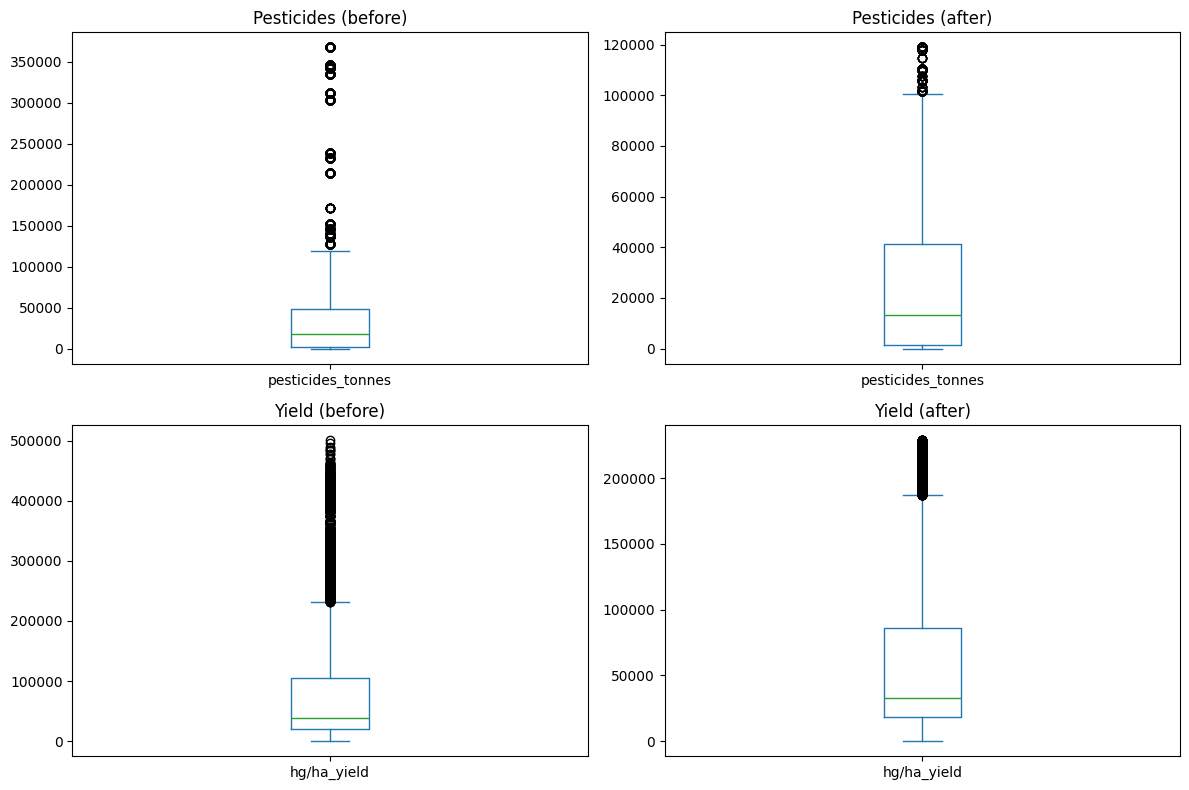

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df2['pesticides_tonnes'].plot(kind='box', ax=axes[0][0], title='Pesticides (before)')
df2_clean['pesticides_tonnes'].plot(kind='box', ax=axes[0][1], title='Pesticides (after)')

df2['hg/ha_yield'].plot(kind='box', ax=axes[1][0], title='Yield (before)')
df2_clean['hg/ha_yield'].plot(kind='box', ax=axes[1][1], title='Yield (after)')

plt.tight_layout()
plt.show()

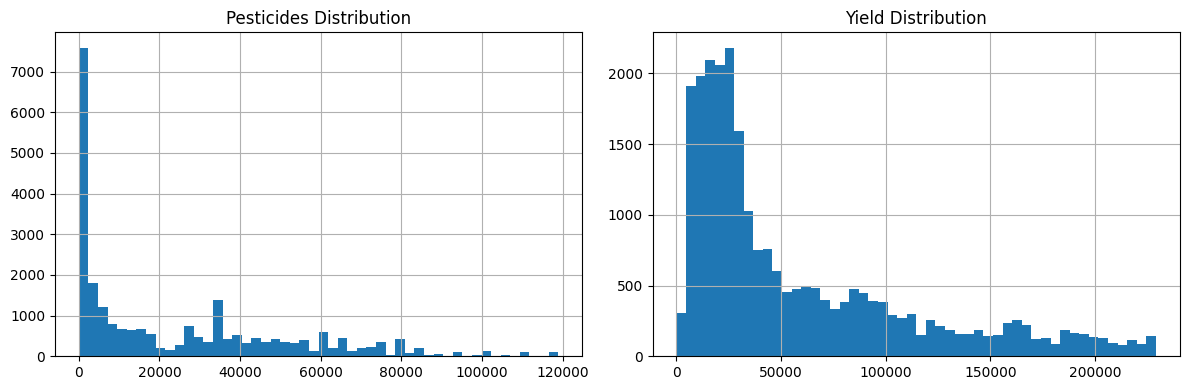

Pesticides - 均值: 24642.17   中位数: 13289.18
Yield      - 均值: 58160.12   中位数: 33177.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df2_clean['pesticides_tonnes'].hist(bins=50, ax=axes[0])
axes[0].set_title('Pesticides Distribution')

df2_clean['hg/ha_yield'].hist(bins=50, ax=axes[1])
axes[1].set_title('Yield Distribution')

plt.tight_layout()
plt.show()

print("Pesticides - 均值:", round(df2_clean['pesticides_tonnes'].mean(), 2),
      "  中位数:", round(df2_clean['pesticides_tonnes'].median(), 2))
print("Yield      - 均值:", round(df2_clean['hg/ha_yield'].mean(), 2),
      "  中位数:", round(df2_clean['hg/ha_yield'].median(), 2))

In [21]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

X = df2_clean.drop(columns=['hg/ha_yield'])
y = df2_clean['hg/ha_yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['Area', 'Item'])
], remainder='passthrough')

model_yield = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model_yield.fit(X_train, y_train)
y_pred = model_yield.predict(X_test)

print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))
print("R2 Score:", round(r2_score(y_test, y_pred), 4))

MAE: 3076.45
R2 Score: 0.9806


In [22]:
print("产量范围：", df2_clean['hg/ha_yield'].min(), "~", df2_clean['hg/ha_yield'].max())
print("产量均值：", round(df2_clean['hg/ha_yield'].mean(), 0))

产量范围： 50 ~ 229141
产量均值： 58160.0


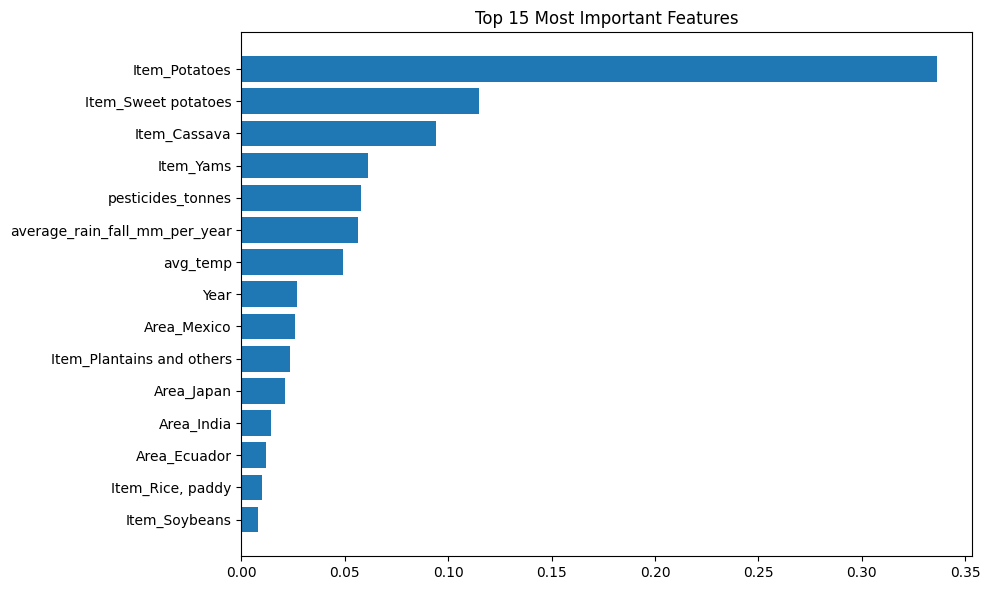

In [23]:
feature_names = (
    model_yield.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(['Area', 'Item']).tolist()
    + ['Year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
)

importances = model_yield.named_steps['regressor'].feature_importances_

feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_df['feature'], feat_df['importance'])
ax.set_title('Top 15 Most Important Features')
ax.invert_yaxis()
plt.tight_layout()
plt.show()